In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os

from PIL import Image

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/images_main/images"

## What are the Image file Extensions

In [5]:
file_extensions = []
for root, dirs, files in os.walk(path):
  print(f"Reading images from {root}, Found {len(files)} files.")
  for file_name in files:
    file_extensions.append(os.path.splitext(file_name)[-1])
    file_path = os.path.join(root, file_name)

print()
print("Total Number of Files:", len(file_extensions))
print("File Extensions:", set(file_extensions))

Reading images from /content/drive/MyDrive/images_main/images, Found 0 files.
Reading images from /content/drive/MyDrive/images_main/images/Trouser, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/Shirt, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/Bag, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/T-shirt-top, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/Coat, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/Dress, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/Sneaker, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/Pullover, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/Ankle-boot, Found 200 files.
Reading images from /content/drive/MyDrive/images_main/images/Sandal, Found 200 files.

Total Number of Files: 2000
File Extensions: 

## What are the image sizes.extensions and modes?

In [6]:
def read_image_files(path):
  images_data = []
  for root, dirs, files in os.walk(path):
    for file_name in files:
      extension = os.path.splitext(file_name)[-1]
      if extension in file_extensions:
        file_path = os.path.join(root, file_name)
        img = Image.open(file_path)
        images_data.append({
            "file_name": file_name,
            "extension": extension,
            "size": img.size,
            "mode": img.mode,
            "dir":root
        })
  return images_data

def load_into_df(images_data):
  df = pd.DataFrame(images_data)
  return df

In [7]:
%%time

images_data = read_image_files(path)

df = load_into_df(images_data)

df.head()


CPU times: user 623 ms, sys: 272 ms, total: 896 ms
Wall time: 34.8 s


,file_name,extension,size,mode,dir
0,Trouser_155.png,.png,"(28, 28)",L,/content/drive/MyDrive/images_main/images/Trouser
1,Trouser_061.png,.png,"(28, 28)",L,/content/drive/MyDrive/images_main/images/Trouser
2,Trouser_000.png,.png,"(28, 28)",L,/content/drive/MyDrive/images_main/images/Trouser
3,Trouser_030.png,.png,"(28, 28)",L,/content/drive/MyDrive/images_main/images/Trouser
4,Trouser_055.png,.png,"(28, 28)",L,/content/drive/MyDrive/images_main/images/Trouser


In [8]:
df['extension'].value_counts()

,count
extension,
.png,2000


In [9]:
df['mode'].value_counts()

,count
mode,
L,2000


In [10]:
df['size'].value_counts()

,count
size,
"(28, 28)",2000


In [11]:
28*28 #784 pixels

784

## Step-1 Loading the Data

In [12]:
def vectorize_image_files(path):
  image_vectors = []
  image_labels = []
  #get the list of folder names(labels)
  labels = [dir_name for dir_name in os.listdir(path) if os.path.isdir(os.path.join(path,dir_name))]
  for label in labels:
    label_dir = os.path.join(path, label)
    #Ensure the directory exists
    if os.path.isdir(label_dir):
      #Iterate through each image in the directory
      for image_file in os.listdir(label_dir):
        image_file_path = os.path.join(label_dir, image_file)
        with Image.open(image_file_path) as img:
          ### Vectorize ###
          img_arr = np.array(img)
          image_vector = img_arr.ravel()
          ##appending labels and pixel vectors into lists
          image_vectors.append(image_vector)
          image_labels.append(label)

  return image_vectors, image_labels

def load_vectors_into_df(image_vectors, image_labels):
  df = pd.DataFrame(image_vectors, columns=[f"pixel_{i}" for i in range(len(image_vectors[0]))])
  df['labels'] = image_labels
  return df

In [13]:
image_vectors, image_labels = vectorize_image_files(os.path.join(path))

image_df = load_vectors_into_df(image_vectors, image_labels)

image_df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,labels
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Trouser
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Trouser
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Trouser
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Trouser
4,0,0,0,0,0,0,0,0,0,26,...,0,0,0,0,0,0,0,0,0,Trouser


Step - 2 Exploratory Data Analysis

In [14]:
image_df.shape

(2000, 785)

In [15]:
image_df['labels'].value_counts()

,count
labels,
Trouser,200
Shirt,200
Bag,200
T-shirt-top,200
Coat,200
Dress,200
Sneaker,200
Pullover,200
Ankle-boot,200


Randomly Generated index: 59
Label of image at 59 index: Trouser

Data Type of Image Array: object
Image Array:
 [[np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0)
  np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(190)
  np.uint8(233) np.uint8(221) np.uint8(216) np.uint8(211) np.uint8(212)
  np.uint8(216) np.uint8(216) np.uint8(197) np.uint8(0) np.uint8(0)
  np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0)
  np.uint8(0)]
 [np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0)
  np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(19) np.uint8(243)
  np.uint8(242) np.uint8(240) np.uint8(244) np.uint8(245) np.uint8(247)
  np.uint8(238) np.uint8(233) np.uint8(244) np.uint8(53) np.uint8(0)
  np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0)
  np.uint8(0)]
 [np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(0)
  np.uint8(0) np.uint8(0) np.uint8(0) np.uint8(90) np.uint8(255)
  np.uint8(2

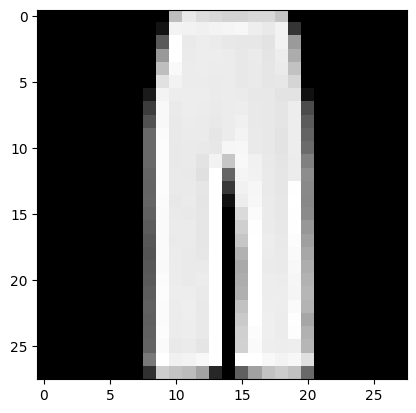

In [16]:
idx = np.random.randint(0, image_df.shape[0]-1)

print("Randomly Generated index:", idx)

print(f"Label of image at {idx} index:", image_df.iloc[idx,-1])
print()

img = np.reshape(image_df.iloc[idx,0:-1], (28,28))

print("Data Type of Image Array:", img.dtype)
print("Image Array:\n",img)

img = img.astype('float')

plt.imshow(img,cmap='gray')

[1750 1081 1864 1191 1358 1006  264 1257  893]


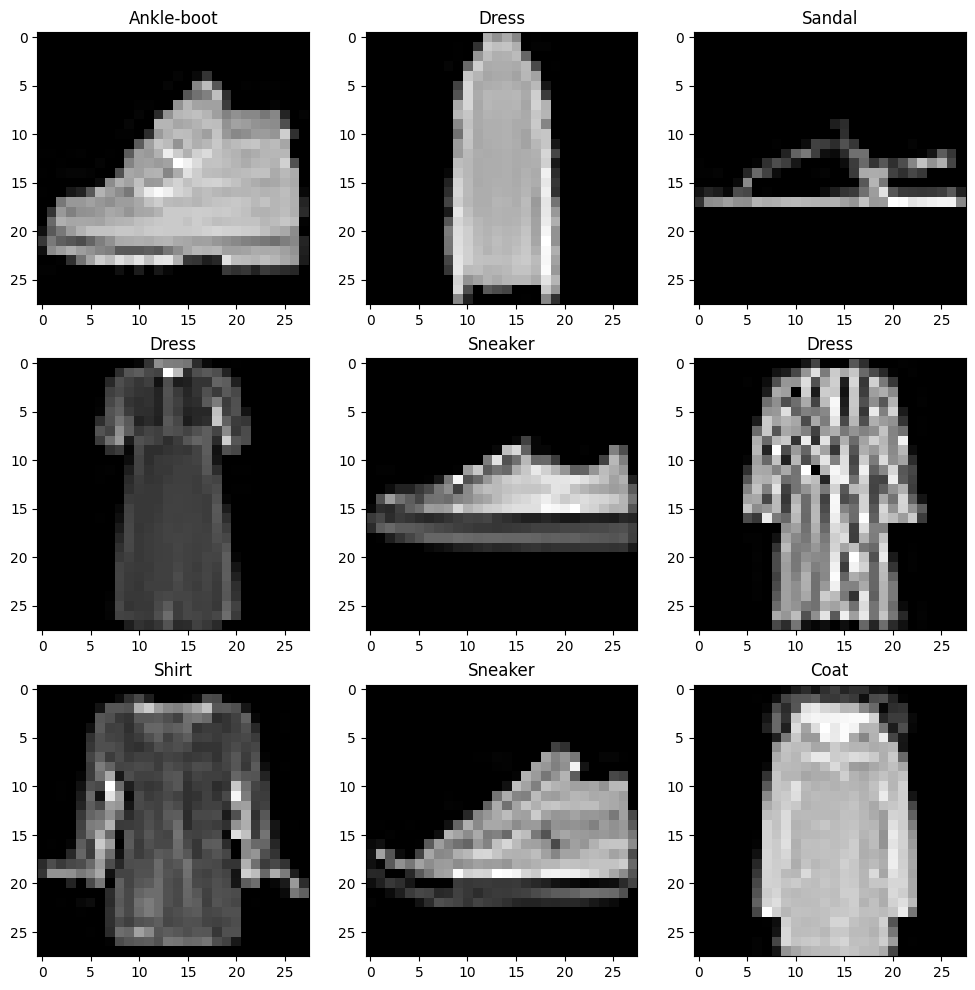

In [17]:
plt.figure(figsize =(12,12))
idx = np.random.randint(0,image_df.shape[0],9)
print(idx)

for i in range(len(idx)):
  plt.subplot(3,3,i+1)
  label = image_df.iloc[idx[i],-1]
  plt.title(label)
  img_grid = np.reshape(image_df.iloc[idx[i], 0:-1],(28,28))
  img_grid = img_grid.astype("float")
  plt.imshow(img_grid, cmap='gray')

## Step-3 Segregate Inputs(X) and Output(y)